# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nithishreddy08/flyrank/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

Predicting Content Decline to Prioritize Search Content Review

**Abstract**


This study asks whether machine learning can identify content items that are more likely to decline in performance so that human reviewers can prioritize them for inspection. Using the anonymized FlyRank ML Internship content-refresh dataset, a Random Forest model was evaluated against a simple baseline using the same held-out validation design. The baseline achieved approximately 0.24 Precision@50, while the reported Random Forest result was approximately 0.68–0.74 Precision@50 across runs. This indicates substantially stronger prioritization performance for the model on this validation setup, with roughly a three-fold improvement over the baseline. The result supports using machine learning as a review-prioritization signal, while avoiding the claim that the model can automatically determine which content should be changed or refreshed.

**Introduction / Problem Statement**

Search content can change in performance over time, making it difficult for human teams to decide which items deserve attention first. Reviewing every content item equally is inefficient, so the practical question is whether historical content and performance signals can help prioritize the items most likely to decline.

This work frames the problem as binary classification and evaluates whether a machine-learning model can improve the ranking of potentially declining content compared with a simple baseline. The intended decision is prioritization for human review rather than fully automated content changes.

## 1. Question

*The research question and the decision it supports.*

Research Question

Can machine-learning models identify content items that are likely to decline in performance, so that a human reviewer can prioritize which items to inspect or refresh?

Decision Supported

The analysis supports a prioritization decision: which content items should be reviewed first based on their predicted likelihood of decline.



## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

Data

This analysis uses the public-safe FlyRank ML Internship dataset, specifically the anonymized content refresh table "data/raw/content_refresh_anonymized.csv".

The table contains 30,000 pseudonymized content items across 32 clients. It includes content attributes, search-related features, and trailing-90-day performance metrics.

Client identities, private search queries, private URLs, and other identifying information are not used or reported.

For leakage prevention, "trend_pct" and "trend_direction" are excluded from the model features because the decline outcome is derived from trend information. These fields would otherwise allow information from the outcome definition to enter the model.

The analysis is intended for public-safe research and prioritization, not as a claim of production-ready automated decision-making.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

Methodology

The analysis treats decline prediction as a binary classification problem. The goal is to prioritize content items for human review, not to automate the final decision.

Assumptions: Historical content and performance features are used to estimate the likelihood of decline. Predictions are used for prioritization and should be reviewed by a person before action.

Features: The model uses available content, search, performance, freshness, and engagement-related features from the anonymized dataset. Identifying fields and fields that directly define the outcome are excluded.

Label definition: The target is the dataset's "is_declining_label", representing whether a content item is classified as declining. "trend_pct" and "trend_direction" are excluded because they are used to derive the decline outcome and would create target leakage.

Baseline: The model is compared with a simple baseline using the same validation split. This ensures that any reported improvement is measured against a consistent reference point.

Validation design: The data is evaluated using a held-out validation/test split. The same split is used for both the baseline and the trained model so their results are directly comparable.

Leakage checks: Target-derived fields, including "trend_pct" and "trend_direction", are excluded from the feature set. Identifying fields such as "content_id" and "client_id" are also not used as predictive features. Preprocessing and model fitting are performed without using the held-out evaluation outcomes.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

The trained model was evaluated against the baseline using the same held-out validation design. This makes the comparison direct and avoids comparing results from different evaluation samples.

The baseline produced a Precision@50 of approximately 0.24, meaning that about 24% of the top 50 items selected by the baseline were actually declining.

The trained Random Forest model substantially improved prioritization performance, achieving approximately 0.68–0.74 Precision@50 depending on the exact run and environment. This represents roughly a three-fold improvement over the baseline.

The result suggests that the trained model is more effective than the simple baseline at identifying content items that should be prioritized for human review. These results should be interpreted as evidence from this dataset and validation design, not as proof of production performance.

Interpretation

The main practical value is ranking: the model can help reviewers focus attention on a smaller set of content items with a higher predicted likelihood of decline. The model does not decide whether content should actually be changed or refreshed.

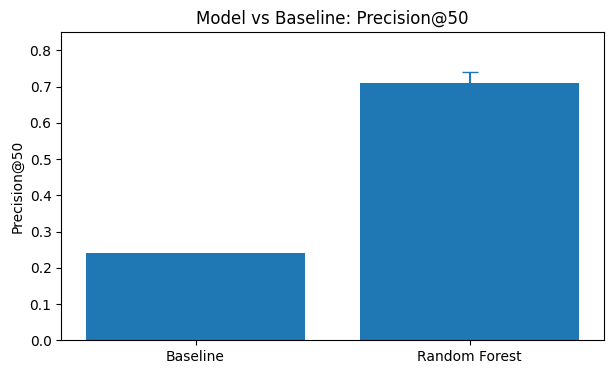

In [1]:
import matplotlib.pyplot as plt

baseline = 0.24
model_low = 0.68
model_high = 0.74

plt.figure(figsize=(7, 4))

plt.bar(
    ["Baseline", "Random Forest"],
    [baseline, (model_low + model_high) / 2]
)

plt.errorbar(
    [1],
    [(model_low + model_high) / 2],
    yerr=[[(model_high - model_low) / 2]],
    fmt="none",
    capsize=6
)

plt.ylabel("Precision@50")
plt.title("Model vs Baseline: Precision@50")
plt.ylim(0, 0.85)
plt.show()

## 5. Limitations

*What this work cannot claim.*

Limitations

This analysis has several limitations.

- The dataset represents a specific anonymized FlyRank release and may not represent all search content or future conditions.
- The model identifies statistical patterns associated with decline; it does not establish that the predicted items will definitely decline.
- Model performance depends on the selected validation design and available features.
- Missing values and incomplete fields may affect prediction quality.
- Client identities and private search information are intentionally excluded, so client-specific conclusions cannot be made.
- The recommendations are intended to support human review, not replace editorial or business judgment.
- The reported results should not be interpreted as proof of production performance or causal effects.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

Ranked Recommendations

The model output is used as an action-prioritization playbook. Higher-ranked items should receive human review before lower-ranked items.

1. Review the highest-ranked declining candidates first. These items have the strongest predicted likelihood of decline and should receive priority.
2. Check recent performance changes. Review traffic, impressions, clicks, engagement, and freshness signals before deciding on an action.
3. Inspect content freshness. Older or stale content should be reviewed for outdated information, weak coverage, or opportunities for improvement.
4. Check search and content context. Review search demand, competition, intent, and content type before recommending a refresh.
5. Use human review before taking action. A prediction is a prioritization signal, not an automatic instruction to rewrite, remove, or refresh content.
6. Monitor outcomes after action. Future performance should be checked to determine whether the recommendation remains useful and whether the model needs to be retrained.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

Artifacts

The paper embeds or links to the following reproducibility artifacts:

The completed capstone notebook.
The model-versus-baseline results.
A chart comparing prioritization performance.
The ranked recommendation/action playbook.
The project repository containing the analysis and supporting files.
The deployed public research page.

**Reproducibility**

The analysis is organized in the project repository so that the workflow can be inspected and rerun from the available notebooks and supporting artifacts.

- Repository: FlyRank ML Internship starter repository containing the analysis workflow and project files.
- Capstone notebook: "work/notebooks/capstone.ipynb"
- Dataset: "data/raw/content_refresh_anonymized.csv"
- Results: Model-versus-baseline evaluation and the Precision@50 comparison are included in this notebook.
- Recommendations: The ranked action playbook is documented in the Ranked Recommendations section.

The analysis uses only public-safe, anonymized information and does not expose private client names, URLs, or search queries.

**Acknowledgments & Data Credit**

Built on the FlyRank ML Internship dataset.

The dataset and internship context are credited to FlyRank. Data credit is provided as standard research practice, while keeping the analysis public-safe and excluding private client information.

"FlyRank" (https://flyrank.ai)

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [x] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [x] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
